# Content Analysis

analysis of the results from pipeline.py

ideas:
- intertitles or _ocr and top 10 words or something 

# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json

from pathlib import Path

# Load & prepare Data

## Load

In [3]:
DATA_DIR = Path("../../data/03_processed") 

records = []

for file_path in DATA_DIR.glob("*.json"):
    with file_path.open(encoding="utf-8") as file:
        record = json.load(file)

    record["_file_name"] = file_path.name
    records.append(record)

df_processed = pd.json_normalize(records, sep="_")
df = df_processed.copy()

# df

## Helper Functions

In [4]:
def parse_meters(value):
    if pd.isna(value):
        return float("nan")

    text = str(value).lower().replace("m", "").strip()
    if not text:
        return float("nan")

    if "," in text:
        text = text.replace(".", "").replace(",", ".")
    else:
        text = text.replace(".", "")

    return pd.to_numeric(text, errors="coerce")

In [5]:
MONTH_NUMBERS = { "januar": 1, "februar": 2, "märz": 3, "april": 4, "mai": 5, "juni": 6, "juli": 7, "august": 8, "september": 9, "oktober": 10, "november": 11, "dezember": 12 }

def parse_german_date(value):
    if pd.isna(value):
        return pd.NaT

    parts = str(value).strip().rstrip(".").split()
    if len(parts) != 3:
        return pd.NaT

    day = parts[0].rstrip(".")
    month = MONTH_NUMBERS.get(parts[1].lower())
    year = parts[2]

    if month is None:
        return pd.NaT

    return pd.to_datetime(
        f"{year}-{month:02d}-{day}",
        errors="coerce",
    )

In [6]:
# Einheitliche Einstellungen für alle Diagramme
PLOT_FIGSIZE = (14, 5)

def format_plot(ax, title, ylabel):
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel('Prüfjahr', fontsize=11, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=8)
    ax.tick_params(axis='both', labelsize=10)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def finish_plot(fig, with_legend=False):
    for ax in fig.axes:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
    rect = (0, 0, 0.84, 1) if with_legend else None
    fig.tight_layout(rect=rect)

def save_plts(fig, name):
    # Titel nur in der gespeicherten Version ausblenden.
    axes_titles = [(ax, ax.title.get_visible()) for ax in fig.axes]
    try:
        for ax, _ in axes_titles:
            ax.title.set_visible(False)
        fig.savefig(name, dpi=300)
    finally:
        for ax, visible in axes_titles:
            ax.title.set_visible(visible)

## Prepare data
join metadata with processed

In [7]:
METADATA_DIR = Path("../../data/01_raw")

if "df_processed" not in globals():
    df_processed = pd.json_normalize(records, sep="_")

metadata_records = []

for file_path in METADATA_DIR.rglob("*.json"):
    with file_path.open(encoding="utf-8") as file:
        metadata_record = json.load(file)

    # Match the metadata file to its corresponding processed file.
    metadata_record["_file_name"] = file_path.name.replace(".json", "_processed.json")
    metadata_records.append(metadata_record)

df_metadata = pd.json_normalize(metadata_records, sep="_")
df_metadata = df_metadata.rename(
    columns={
        column: f"metadata_{column}"
        for column in df_metadata.columns
        if column != "_file_name"
    }
)

df = df_processed.merge(
    df_metadata,
    on="_file_name",
    how="left",
    validate="one_to_one",
    indicator="_metadata_join",
)
df["metadata_available"] = df.pop("_metadata_join").eq("both")

# df

In [8]:
df["examination_number_parsed"] = pd.to_numeric(df["examination_number"], errors="coerce").astype("Int64")
df["metadata_Prüfnummer_parsed"] = pd.to_numeric(df["metadata_Prüfnummer"], errors="coerce").astype("Int64")

df["metadata_Länge_parsed"] = df["metadata_Länge (in Meter)"].apply(parse_meters)
# df["length_details_individual_acts"] ???
df["total_original_length_parsed"] = df["length_details_total_length_original_length"].apply(parse_meters)
df["total_length_after_cut_parsed"] = df["length_details_total_length_length_after_cut"].apply(parse_meters)

df["examination_certificate_date_parsed"] = df["examination_certificate_date"].apply(parse_german_date) # nicht jedes wird geparsed aufgrund von schlechter ocr erkennung hmmm
df["metadata_Prüfdatum_parsed"] = pd.to_datetime(df["metadata_Prüfdatum"], dayfirst=True, errors="coerce")
df["metadata_year"] = df["metadata_Prüfdatum_parsed"].dt.year.astype("Int64")

In [9]:
df.loc[df["metadata_year"].eq(1917), ["_file_name", "metadata_year", "examination_certificate_date"]]

,_file_name,metadata_year,examination_certificate_date
85,R 9346-I_27347_processed.json,1917,27. Januar 1937
1188,R 9346-I_27363_processed.json,1917,16. Februar 1937
2511,R 9346-I_27293_processed.json,1917,16. Januar 1937


OBVIOUS ERRORS

In [10]:
df.loc[df["_file_name"] == "R 9346-I_27347_processed.json", "metadata_year"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27363_processed.json", "metadata_year"] = 1937
df.loc[df["_file_name"] == "R 9346-I_27293_processed.json", "metadata_year"] = 1937

In [11]:
with pd.option_context("display.max_columns", None):
    display(df)

,examination_number,stamp_text,origin_company,movie_title,movie_subtitle,produced_by,director,cinematography,set_design,cast_list,excerpt_note,intertitles,_file_name,length_details_individual_acts,length_details_total_length_original_length,length_details_total_length_length_after_cut,examination_certificate_examination_board,examination_certificate_location,examination_certificate_date,examination_certificate_decision_text,metadata_Titel_und_Signatur,metadata_Prüfnummer,metadata_Prüfdatum,metadata_Antragsteller,metadata_Produktion,metadata_Land,metadata_Filmart,metadata_Stumm-/Tonfilm,metadata_Länge (in Meter),metadata_Entscheidung,metadata_Unterlagenart,metadata_Benutzungsort,metadata_Bemerkung,metadata_Vorführungsbeschränkung,metadata_Ort des Prüfdatums,metadata_available,examination_number_parsed,metadata_Prüfnummer_parsed,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,examination_certificate_date_parsed,metadata_Prüfdatum_parsed,metadata_year
0,11751,Zulassungskarten für Bildstreifen sind öffentl...,"Universal Pictures Corp., New York",Liebestoll.,NaN,Deutsch-Nordische Film-Union G. m. b. H.,NaN,NaN,NaN,[],NaN,"[{'act_label': '1. Akt', 'text': '1. Akt. 1. E...",R 9346-I_7746_processed.json,"[{'act_number': 'I', 'original_length': '260 m...",498 m,NaN,Film-Prüfstelle Berlin,Berlin,13. November 1935,Der Bildstreifen wird zur öffentlichen Vorführ...,R 9346-I/7746\nLiebestoll.\n1920 - 1945,11751,13.11.1925,"Deutsch-Nordische Film-Union GmbH, Berlin","Universal-Pictures Corp., New York",USA,Spielfilm,Stummfilm,498,Jugendverbot,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,11751,11751,498.0,498.0,NaN,1935-11-13,1925-11-13,1925
1,38954,Zulassungskarten für Filme sind öffentliche Ur...,"Gebrüder Diehl-Film, Gräfeling bei München",Die Macht der Liebe.,Tobis zeigt einen Puppenfilm der Gebrüder Dieh...,Killerstraße 10/1.,NaN,Hans Asen,NaN,[],NaN,"[{'act_label': 'Fortsetzung', 'text': '2. Aha,...",R 9346-I_24154_processed.json,[],580 m,NaN,Film-Prüfstelle,Berlin,29. März 1935,Der Film wird zur öffentlichen Vorführung im D...,R 9346-I/24154\nDie Macht der Liebe\n1920 - 1945,38954,29.3.1935,"Gebr. Diehl, Gräfelfing b. München","Gebr. Diehl, Gräfelfing b. München",Deutschland,Spielfilm,Tonfilm,580,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,38954,38954,580.0,580.0,NaN,1935-03-29,1935-03-29,1935
2,16811,Zulassungskarten für Bildstreifen sind öffentl...,"Paramount-Film, U. S. A.",Ko Ko als Wedder.,Alfred Weiß zeigt Tintenmännchen im: Ko Ko als...,Universum-Film Aktiengesellschaft Berlin SW 68...,NaN,NaN,NaN,[],NaN,[],R 9346-I_11484_processed.json,[],181 m,NaN,Film-Prüfstelle Berlin,Berlin,3. Oktober 1927,Der Bildstreifen wird zur öffentlichen Vorführ...,R 9346-I/11484\nKo Ko als Wecker.\n1920 - 1945,16811,3.10.1927,"Universum-Film AG, Berlin","Paramount, New York",USA,Zeichentrickfilm,Stummfilm,181,Jugendfrei,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,16811,16811,181.0,181.0,NaN,1927-10-03,1927-10-03,1927
3,57539,NaN,"Tobis Filmkunst G. m. b. H., Berlin NW 7",Die Entlassung.,Tobis zeigt Emil Jannings in: Die Entlassung.,Friedrichstraße 100,Wolfgang Liebeneiner,Fritzz Wagner,Otto Hunte,"[{'role': 'Fürst Bismarck', 'actor': 'Emil Jan...",NaN,"[{'act_label': '1. Akt', 'text': '1. Vor dem A...",R 9346-I_35012_processed.json,"[{'act_number': '1. Rolle 1. Akt', 'original_l...",2991 m,NaN,Filmprüfstelle,Berlin,28. August 1942,Der Film wird zur öffentlichen Vorführung im D...,R 9346-I/35012\nDie Entlassung\n1920 - 1945,57539,28.8.1942,"Tobis Filmkunst GmbH, Berlin","Tobis Filmkunst GmbH, Berlin",Deutschland,Spielfilm,Tonfilm,2991,Jugendfrei vom 14. Lebensjahr ab,Zulassungskarte,Berlin-Lichterfelde,NaN,NaN,NaN,True,57539,57539,2991.0,2991.0,NaN,1942-08-28,1942-08-28,1942
4,15543,Zulassungskarten für Bildstreifen sind öffent....,"Berlin W 35, Genhinter Straße 32",Die Entstehung der Pelzmode.,Pinschewer-Film. 1. Frau Eva spricht zu ihrem ...,"Werbefilm G. m. b. H., Leitung J. Pin

In [12]:
# Titel und Signatur
def parse_title(df, column_name):
    return df[column_name].str.split('\n').str[1] 

df["metadata_Titel"] = parse_title(df, "metadata_Titel_und_Signatur")
df["movie_title_parsed"] = df["movie_title"].str.replace('.', '', regex=False)


df_look = df[df["metadata_Titel"].isna()]
with pd.option_context("display.max_columns", None):
    display(df_look)

,examination_number,stamp_text,origin_company,movie_title,movie_subtitle,produced_by,director,cinematography,set_design,cast_list,excerpt_note,intertitles,_file_name,length_details_individual_acts,length_details_total_length_original_length,length_details_total_length_length_after_cut,examination_certificate_examination_board,examination_certificate_location,examination_certificate_date,examination_certificate_decision_text,metadata_Titel_und_Signatur,metadata_Prüfnummer,metadata_Prüfdatum,metadata_Antragsteller,metadata_Produktion,metadata_Land,metadata_Filmart,metadata_Stumm-/Tonfilm,metadata_Länge (in Meter),metadata_Entscheidung,metadata_Unterlagenart,metadata_Benutzungsort,metadata_Bemerkung,metadata_Vorführungsbeschränkung,metadata_Ort des Prüfdatums,metadata_available,examination_number_parsed,metadata_Prüfnummer_parsed,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,examination_certificate_date_parsed,metadata_Prüfdatum_parsed,metadata_year,metadata_Titel,movie_title_parsed
1450,54802,Zulassungskarten für Filme sind öffentliche Ur...,"Gasparcolor Werbefilme G. m. b. H., Berlin W 50",Der Imbert-Generator.,"Ein Film der Gasparcolor-Film, Berlin W 50.","Paul Schwärzel,\nunter Mitarbeit von Hasso Pre...",NaN,NaN,NaN,[],NaN,[],R_9346_I_33595_processed.json,[],NaN,NaN,Film-Prüfstelle,Berlin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,54802,<NA>,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,Der Imbert-Generator


# Analysis

In [13]:
counts_per_year = df["metadata_year"].value_counts().sort_index()

counts_per_year

metadata_year
1920     71
1921    120
1922    120
1923    120
1924    120
1925    120
1926    120
1927    120
1928    120
1929    120
1930    120
1931     84
1932    109
1933    120
1934     80
1935     83
1936    120
1937    123
1938    120
1939    120
1940    120
1941    119
1942    115
1943    112
1944    115
1945     12
Name: count, dtype: Int64

## Filmlength & cuts

Film ungeschnitten:
- `length after cut`fehlt 
- in den einzlenen Akten keine `length after cut` angaben vorhanden ist # lowkey unnötig?

nicht bestimmbar
- fälle mit widersprüchlichen/unollständigen cut angaben
- z.B. cut größer als eigentliche länge
- => 10 nicht bestimmbar 

---

- kürzungen/länge pro jahr?
- durchschnittliche kürzung pro jahr?
- median der kürzung pro jahr?
- anteil der filme mit kürzungen?


In [14]:
df_filmlength = df[[
    "_file_name", 
    "movie_title",
    "metadata_year",
    "metadata_Entscheidung",
    "metadata_Länge_parsed", 
    "total_original_length_parsed", 
    "total_length_after_cut_parsed", 
    "length_details_individual_acts"
]].copy()

def has_after_cut_length(acts):
    if not isinstance(acts, list):
        return False

    return any(
        isinstance(act, dict)
        and pd.notna(parse_meters(act.get("length_after_cut")))
        for act in acts
    )

df_filmlength["cut_length_in_acts_available"] = (
    df_filmlength["length_details_individual_acts"].apply(has_after_cut_length)
)
df_filmlength["cut_length_available"] = (
    df_filmlength["total_original_length_parsed"].notna()
    & df_filmlength["total_length_after_cut_parsed"].notna()
)

valid_lengths = (
    df_filmlength["cut_length_available"]
    & df_filmlength["total_original_length_parsed"].gt(0)
    & df_filmlength["total_length_after_cut_parsed"].le(df_filmlength["total_original_length_parsed"])
)

# Fehlt jede Angabe zu einem Schnitt, wird der Film als ungeschnitten
# behandelt. Unvollständige Cut-Angaben bleiben dagegen unbekannt.
df_filmlength["uncut_inferred"] = (
    df_filmlength["total_length_after_cut_parsed"].isna()
    & ~df_filmlength["cut_length_in_acts_available"]
)

df_filmlength["cut_meters"] = (
    df_filmlength["total_original_length_parsed"] - df_filmlength["total_length_after_cut_parsed"]
).where(valid_lengths)
df_filmlength.loc[df_filmlength["uncut_inferred"], "cut_meters"] = 0

df_filmlength["cut_rate"] = (
    df_filmlength["cut_meters"] / df_filmlength["total_original_length_parsed"]
).where(valid_lengths)

df_filmlength.loc[
    df_filmlength["uncut_inferred"]
    & df_filmlength["total_original_length_parsed"].gt(0),
    "cut_rate",
] = 0

df_filmlength["length_after_cut_for_analysis"] = (
    df_filmlength["total_length_after_cut_parsed"]
    .where(valid_lengths)
)
df_filmlength.loc[
    df_filmlength["uncut_inferred"],
    "length_after_cut_for_analysis",
] = df_filmlength.loc[
    df_filmlength["uncut_inferred"],
    "total_original_length_parsed",
]

df_filmlength["cut_status"] = "nicht bestimmbar"
df_filmlength.loc[
    df_filmlength["uncut_inferred"]
    | (valid_lengths & df_filmlength["cut_meters"].eq(0)),
    "cut_status",
] = "ungeschnitten"
df_filmlength.loc[
    valid_lengths & df_filmlength["cut_meters"].gt(0),
    "cut_status",
] = "geschnitten"

df_filmlength["films_with_cut"] = df_filmlength["cut_status"].eq("geschnitten")
df_filmlength["films_without_cut"] = df_filmlength["cut_status"].eq("ungeschnitten")
df_filmlength["cut_status_unknown"] = df_filmlength["cut_status"].eq("nicht bestimmbar")

df_filmlength

,_file_name,movie_title,metadata_year,metadata_Entscheidung,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,length_details_individual_acts,cut_length_in_acts_available,cut_length_available,uncut_inferred,cut_meters,cut_rate,length_after_cut_for_analysis,cut_status,films_with_cut,films_without_cut,cut_status_unknown
0,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,"[{'act_number': 'I', 'original_length': '260 m...",False,False,True,0.0,0.0,498.0,ungeschnitten,False,True,False
1,R 9346-I_24154_processed.json,Die Macht der Liebe.,1935,Jugendfrei,580.0,580.0,NaN,[],False,False,True,0.0,0.0,580.0,ungeschnitten,False,True,False
2,R 9346-I_11484_processed.json,Ko Ko als Wedder.,1927,Jugendfrei,181.0,181.0,NaN,[],False,False,True,0.0,0.0,181.0,ungeschnitten,False,True,False
3,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,"[{'act_number': '1. Rolle 1. Akt', 'original_l...",False,False,True,0.0,0.0,2991.0,ungeschnitten,False,True,False
4,R 9346-I_10472_processed.json,Die Entstehung der Pelzmode.,1927,Jugendfrei,94.0,94.0,NaN,[],False,False,True,0.0,0.0,94.0,ungeschnitten,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,R 9346-I_20179_processed.json,Mann über Bord.,1931,Jugendverbot,2200.0,2200.0,NaN,"[{'act_number': 'I', 'original_length': '292 m...",False,False,True,0.0,0.0,2200.0,ungeschnitten,False,True,False
2820,R 9346-I_5875_processed.json,Gehöhrte Räuber.,1924,Jugendfrei,393.0,393.0,NaN,[],False,False,True,0.0,0.0,393.0,ungeschnitten,False,True,False
2821,R 9346-I_4696_processed.json,Die Wölfin.,1923,Jugendfrei,539.0,539.0,NaN,"[{'act_number': 'I', 'original_length': '241 m...",False,False,True,0.0,0.0,539.0,ungeschnitten,False,True,False
2822,R 9346-I_29422_processed.json,Neue Möbel im neuen Heim. (Schmalfilm.),1938,Jugendfrei,16.0,16.0,NaN,[],False,False,True,0.0,0.0,16.0,ungeschnitten,False,True,False


In [15]:
yearly_length = (
    df_filmlength.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        records=("_file_name", "count"),
        records_with_original_length=("total_original_length_parsed", "count"),
        records_with_after_cut_length=("cut_length_available", "sum"),
        records_with_cut_status=("cut_status", lambda values: values.ne("nicht bestimmbar").sum()),
        films_with_cut=("films_with_cut", "sum"),
        films_without_cut=("films_without_cut", "sum"),
        records_cut_status_unknown=("cut_status_unknown", "sum"),
        records_length=("total_original_length_parsed", "sum"),
        records_cut_meters=("cut_meters", "sum"),

        metadata_Länge_mean=("metadata_Länge_parsed", "mean"),
        metadata_Länge_median=("metadata_Länge_parsed", "median"),

        total_original_length_mean=("total_original_length_parsed", "mean"),
        total_original_length_median=("total_original_length_parsed", "median"),

        total_length_after_cut_mean=("length_after_cut_for_analysis", "mean"),
        total_length_after_cut_median=("length_after_cut_for_analysis", "median"),

        cut_meters_mean=("cut_meters", "mean"),
        cut_meters_median=("cut_meters", "median"),
        cut_rate_mean=("cut_rate", "mean"),
        cut_rate_median=("cut_rate", "median")
    )
)

yearly_length["cut_share_percent"] = (
    yearly_length["films_with_cut"]
    .div(yearly_length["records"])
    .mul(100)
    .where(yearly_length["records"].gt(0))
)
yearly_length["uncut_share_percent"] = (
    yearly_length["films_without_cut"]
    .div(yearly_length["records"])
    .mul(100)
    .where(yearly_length["records"].gt(0))
)

yearly_length.round(2)

,records,records_with_original_length,records_with_after_cut_length,records_with_cut_status,films_with_cut,films_without_cut,records_cut_status_unknown,records_length,records_cut_meters,metadata_Länge_mean,...,total_original_length_mean,total_original_length_median,total_length_after_cut_mean,total_length_after_cut_median,cut_meters_mean,cut_meters_median,cut_rate_mean,cut_rate_median,cut_share_percent,uncut_share_percent
metadata_year,,,,,,,,,,,,,,,,,,,,,
1920,71,71,10,71,10,61,0,89135.0,192.50,1258.80,...,1255.42,1315.0,1252.71,1315.0,2.71,0.0,0.00,0.0,14.08,85.92
1921,120,116,17,117,14,103,3,119430.0,219.35,1035.22,...,1029.57,998.5,993.94,920.0,1.87,0.0,0.00,0.0,11.67,85.83
1922,120,116,3,120,3,117,0,89315.0,44.25,767.97,...,769.96,385.0,769.58,385.0,0.37,0.0,0.00,0.0,2.50,97.50
1923,120,118,8,120,8,112,0,110073.0,79.25,931.75,...,932.82,552.5,932.15,552.5,0.66,0.0,0.00,0.0,6.67,93.33
1924,120,118,5,119,5,114,1,113945.0,103.50,964.28,...,965.64,636.0,970.13,639.0,0.87,0.0,0.00,0.0,4.17,95.00
1925,120,118,0,120,0,120,0,90144.0,0.00,757.47,...,763.93,477.5,763.93,477.5,0.00,0.0,0.00,0.0,0.00,100.00
1926,120,117,6,119,5,114,1,85655.0,107.70,708.90,...,732.09,308.0,719.72,302.0,0.91,0.0,0.00,0.0,4.17,95.00
1927,120,119,4,120,4,116,0,79012.0,14.73,661.33,...,663.97,250.0,663.84,250.0,0.12,0.0,0.00,0.0,3.33,96.67
1928,120,119,6,120,6,114,0,80020.0,1080.45,676.69,...,672.44,270.0,663.36,269.0,9.00,0.0,0.01,0.0,5.00,95.00


In [16]:
film_type_data = df.loc[
    df["metadata_year"].notna(),
    ["metadata_year", "metadata_Filmart"],
].copy()
film_type_data["metadata_Filmart"] = (
    film_type_data["metadata_Filmart"]
    .fillna("(fehlend)")
    .replace("", "(fehlend)")
)

yearly_film_type_share = (
    pd.crosstab(
        film_type_data["metadata_year"],
        film_type_data["metadata_Filmart"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)
yearly_film_type_share.index.name = "metadata_year"

yearly_film_type_share

metadata_Filmart,(fehlend),Dokumentarfilm,Kulturfilm,Puppenfilm,Spielfilm,Trickfilm,Werbefilm,Zeichentrickfilm
metadata_year,,,,,,,,
1920,0.00,0.00,14.08,1.41,71.83,0.00,8.45,4.23
1921,0.83,0.00,25.00,0.00,70.00,0.00,4.17,0.00
1922,0.00,0.00,49.17,0.00,46.67,0.00,4.17,0.00
1923,0.00,0.83,32.50,0.00,55.83,0.00,10.00,0.83
1924,0.00,0.00,33.33,0.00,57.50,0.00,9.17,0.00
1925,0.00,0.83,46.67,0.00,45.83,0.00,6.67,0.00
1926,0.00,0.00,48.33,0.00,38.33,0.00,13.33,0.00
1927,0.00,0.00,35.83,0.00,41.67,0.83,20.00,1.67
1928,0.83,0.00,40.00,0.00,33.33,0.00,25.00,0.83


In [17]:
# Detailanalyse des Peaks von 1934
# Die Grafik basiert auf total_original_length_parsed (Originallänge in Metern).
length_detail_columns = [
    "_file_name",
    "examination_number",
    "metadata_year",
    "metadata_Titel",
    "movie_title",
    "metadata_Land",
    "metadata_Filmart",
    "metadata_Stumm-/Tonfilm",
    "metadata_Antragsteller",
    "metadata_Entscheidung",
    "metadata_Länge_parsed",
    "total_original_length_parsed",
]

length_detail = (
    # df.loc[df["metadata_year"].isin([1920, 1921, 1922, 1933, 1934, 1935, 1943, 1944, 1945]), length_detail_columns]
    df.loc[df["metadata_year"].isin([1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945]), length_detail_columns]
    .merge(
        df_filmlength[["_file_name", "length_after_cut_for_analysis", "cut_status"]],
        on="_file_name",
        how="left",
        validate="one_to_one",
    )
    .dropna(subset=["total_original_length_parsed"])
    .assign(
        share_of_year_total=lambda frame: (
            frame["total_original_length_parsed"]
            / frame.groupby("metadata_year")["total_original_length_parsed"].transform("sum")
            * 100
        )
    )
)

peak_comparison = (
    length_detail.groupby("metadata_year")["total_original_length_parsed"]
    .agg(
        filme="count",
        mittelwert="mean",
        median="median",
        q75=lambda values: values.quantile(0.75),
        q90=lambda values: values.quantile(0.90),
        maximum="max",
        gesamtlänge="sum",
    )
)

display(peak_comparison.round(2))

films_1920 = (
    length_detail[length_detail["metadata_year"].eq(1920)]
    .sort_values("total_original_length_parsed", ascending=False)
)

display(
    films_1920[
        [
            "metadata_Titel",
            "movie_title",
            "total_original_length_parsed",
            "length_after_cut_for_analysis",
            "share_of_year_total",
            "metadata_Land",
            "metadata_Filmart",
            "metadata_Entscheidung",
            "_file_name",
        ]
    ].head(20).round(2)
)

films_1945 = (
    length_detail[length_detail["metadata_year"].eq(1945)]
    .sort_values("total_original_length_parsed", ascending=False)
)

display(
    films_1945[
        [
            "metadata_Titel",
            "movie_title",
            "total_original_length_parsed",
            "length_after_cut_for_analysis",
            "share_of_year_total",
            "metadata_Land",
            "metadata_Filmart",
            "metadata_Entscheidung",
            "_file_name",
        ]
    ].head(20).round(2)
)

,filme,mittelwert,median,q75,q90,maximum,gesamtlänge
metadata_year,,,,,,,
1920,71,1255.42,1315.0,1971.00,2392.0,3448.0,89135.0
1921,116,1029.57,998.5,1676.75,2018.5,3070.0,119430.0
1922,116,769.96,385.0,1445.00,1970.5,3170.0,89315.0
1923,118,932.82,552.5,1647.00,2058.3,2558.0,110073.0
1924,118,965.64,636.0,1696.50,2062.0,3150.0,113945.0
1925,118,763.93,477.5,1177.25,2022.4,3027.0,90144.0
1926,117,732.09,308.0,1010.00,2067.4,3667.0,85655.0
1927,119,663.97,250.0,643.00,2127.2,2766.0,79012.0
1928,119,672.44,270.0,961.50,2202.4,2863.0,80020.0


,metadata_Titel,movie_title,total_original_length_parsed,length_after_cut_for_analysis,share_of_year_total,metadata_Land,metadata_Filmart,metadata_Entscheidung,_file_name
653,Veritas vincit,Veritas vincit. (Die Wahrheit siegt.),3448.0,3448.0,3.87,Deutschland,Spielfilm,Jugendverbot,R 9346-I_139_processed.json
1643,Schieber,Schieber.,2889.0,2889.0,3.24,Deutschland,Spielfilm,Jugendverbot,R 9346-I_115_processed.json
2401,Die Schuld der Lavinia Morland.,Die Schuld der Lavinia Morland.,2662.0,2662.0,2.99,Deutschland,Spielfilm,Jugendverbot,R 9346-I_134_processed.json
2114,Figaros Hochzeit,Figaros Hochzeit.,2482.0,2482.0,2.78,Deutschland,Spielfilm,Jugendverbot,R 9346-I_38_processed.json
1422,Die entfesselte Menschheit,Die entstellte Menschheit.,2453.0,2453.0,2.75,Deutschland,Spielfilm,Jugendverbot,R 9346-I_5_processed.json
2136,Sumurum.,Sumurun.,2400.0,2379.0,2.69,Deutschland,Spielfilm,Jugendverbot,R 9346-I_25_processed.json
2788,Anna Boleyn,Haus Kleen.,2393.0,2393.0,2.68,Deutschland,Spielfilm,Jugendverbot,R 9346-I_155_processed.json
1699,Die Luftpiraten,Die Lustspiele.,2392.0,2384.0,2.68,Deutschland,Spielfilm,Jugendverbot,R 9346-I_18_processed.json
1050,Die Spieler,Die Spieler.,2379.0,2379.0,2.67,Deutschland,Spielfilm,Jugendverbot,R 9346-I_2_processed.json
2505,Grausige Nächte,Granstige Nähen.,2310.0,2310.0,2.59,Deutschland,Spielfilm,Jugendverbot,R 9346-I_26_processed.json


,metadata_Titel,movie_title,total_original_length_parsed,length_after_cut_for_analysis,share_of_year_total,metadata_Land,metadata_Filmart,metadata_Entscheidung,_file_name
253,Viel Lärm um Nixi,Viel Lärm um Nixi.,2816.0,2816.0,11.43,Deutschland,Spielfilm,Jugendverbot,R 9346-I_36456_processed.json
1168,Der stumme Gast.,Der stumme Gast.,2806.0,2806.0,11.39,Deutschland,Spielfilm,Jugendverbot,R 9346-I_36465_processed.json
326,Tanz mit dem Kaiser,Tanz mit dem Kaiser.,2773.0,2773.0,11.26,Deutschland,Spielfilm,Jugendverbot,R 9346-I_36462_processed.json
1913,Die Kellnerin Anna,Die Kellnerin Anna.,2766.0,2766.0,11.23,Deutschland,Spielfilm,Jugendfrei,R 9346-I_36468_processed.json
1806,Die Stimme aus dem Äther,Die Stimme aus dem Äther.,2590.0,2590.0,10.52,Deutschland,Spielfilm,Jugendfrei,R 9346-I_36467_processed.json
2271,Die Frau am Scheidewege.,Die Frau am Scheidewege.,2562.0,2562.0,10.40,Ungarn,Spielfilm,Jugendverbot,R 9346-I_36455_processed.json
104,Sophienlund,Sophienlund.,2506.0,2506.0,10.17,Deutschland,Spielfilm,Jugendfrei,R 9346-I_36466_processed.json
1221,Der Strom.,Der Strom.,2430.0,2430.0,9.87,Deutschland,Spielfilm,Jugendfrei vom 14. Lebensjahr ab,R 9346-I_36463_processed.json
877,Zwei in einer grossen Stadt,Zwei in einer großen Stadt.,2219.0,2219.0,9.01,Deutschland,Spielfilm,Jugendfrei,R 9346-I_36464_processed.json
1293,Unsere Jungen (Ein Film der National-politisch...,Unsere Jungen.,528.0,528.0,2.14,Deutschland,Dokumentarfilm,Jugendfrei,R 9346-I_35445_processed.json


### Filmlängen-Ausreißer über den gesamten Zeitraum

$$
IQR = Q3 - Q1
$$
$$
x < Q1 - 1,5 * IQR oder x > Q3 + 1,5 * IQR
$$


In [18]:
filmlength_data_all_years = df_filmlength.dropna(
    subset=["metadata_year", "total_original_length_parsed"]
).copy()

filmlength_Q1_all_years = filmlength_data_all_years["total_original_length_parsed"].quantile(0.25)
filmlength_Q3_all_years = filmlength_data_all_years["total_original_length_parsed"].quantile(0.75)
filmlength_IQR_all_years = filmlength_Q3_all_years - filmlength_Q1_all_years
filmlength_lower_bound_all_years = filmlength_Q1_all_years - 1.5 * filmlength_IQR_all_years
filmlength_upper_bound_all_years = filmlength_Q3_all_years + 1.5 * filmlength_IQR_all_years

outlier_columns = [
    "metadata_year",
    "movie_title",
    "total_original_length_parsed",
    "_file_name",
]

lower_outliers = (
    filmlength_data_all_years.loc[
        filmlength_data_all_years["total_original_length_parsed"]
        < filmlength_lower_bound_all_years,
        outlier_columns,
    ]
    .assign(outlier_type="lower")
)
upper_outliers = (
    filmlength_data_all_years.loc[
        filmlength_data_all_years["total_original_length_parsed"]
        > filmlength_upper_bound_all_years,
        outlier_columns,
    ]
    .assign(outlier_type="upper")
)

filmlength_outliers_all_years = (
    pd.concat([lower_outliers, upper_outliers], ignore_index=True)
    .assign(
        Q1=filmlength_Q1_all_years,
        Q3=filmlength_Q3_all_years,
        IQR=filmlength_IQR_all_years,
        lower_bound=filmlength_lower_bound_all_years,
        upper_bound=filmlength_upper_bound_all_years,
    )
    .sort_values(
        ["metadata_year", "total_original_length_parsed"],
        ascending=[True, False],
    )
)

filmlength_outliers_all_years

,metadata_year,movie_title,total_original_length_parsed,_file_name,outlier_type,Q1,Q3,IQR,lower_bound,upper_bound
33,1920,Veritas vincit. (Die Wahrheit siegt.),3448.0,R 9346-I_139_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
94,1920,Schieber.,2889.0,R 9346-I_115_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
128,1920,Die Schuld der Lavinia Morland.,2662.0,R 9346-I_134_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
56,1921,König Nicolo oder: So ist er leben.,3070.0,R 9346-I_6_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
133,1921,Memorien eines Kammerdieters.,2832.0,R 9346-I_567_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
...,...,...,...,...,...,...,...,...,...,...
66,1945,Der stumme Gast.,2806.0,R 9346-I_36465_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
18,1945,Tanz mit dem Kaiser.,2773.0,R 9346-I_36462_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
104,1945,Die Kellnerin Anna.,2766.0,R 9346-I_36468_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
97,1945,Die Stimme aus dem Äther.,2590.0,R 9346-I_36467_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5


In [19]:
years = filmlength_data_all_years["metadata_year"].drop_duplicates().sort_values()

outliers_per_year = (
    filmlength_outliers_all_years
    .groupby(["metadata_year", "outlier_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(years, fill_value=0)
    .reindex(columns=["lower", "upper"], fill_value=0)
    .rename(
        columns={
            "lower": "lower_outlier_count",
            "upper": "upper_outlier_count",
        }
    )
    .astype(int)
)
outliers_per_year["total_outlier_count"] = (
    outliers_per_year["lower_outlier_count"]
    + outliers_per_year["upper_outlier_count"]
)

outliers_per_year

outlier_type,lower_outlier_count,upper_outlier_count,total_outlier_count
metadata_year,,,
1920,0,3,3
1921,0,4,4
1922,0,1,1
1923,0,1,1
1924,0,3,3
1925,0,4,4
1926,0,2,2
1927,0,3,3
1928,0,3,3


In [20]:
def filmlength_outliers_for_year(year):
    return (
        filmlength_outliers_all_years
        .loc[filmlength_outliers_all_years["metadata_year"].eq(year)]
        .sort_values(
            ["outlier_type", "total_original_length_parsed"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

filmlength_outliers_for_year(1920)

,metadata_year,movie_title,total_original_length_parsed,_file_name,outlier_type,Q1,Q3,IQR,lower_bound,upper_bound
0,1920,Veritas vincit. (Die Wahrheit siegt.),3448.0,R 9346-I_139_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
1,1920,Schieber.,2889.0,R 9346-I_115_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5
2,1920,Die Schuld der Lavinia Morland.,2662.0,R 9346-I_134_processed.json,upper,115.0,1078.0,963.0,-1329.5,2522.5


### Plots

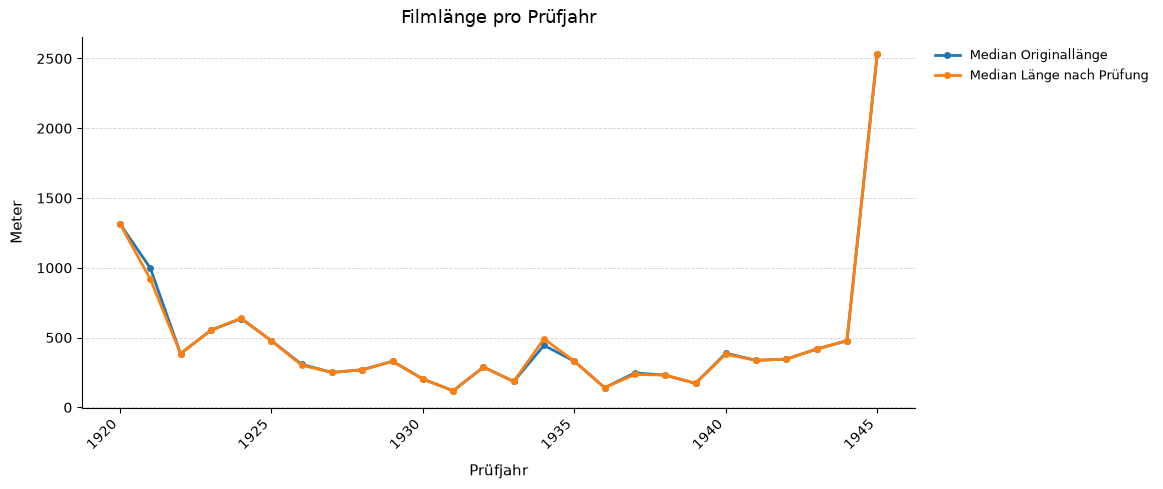

In [21]:
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

ax.plot(
    yearly_length.index,
    yearly_length["total_original_length_median"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="Median Originallänge",
)
ax.plot(
    yearly_length.index,
    yearly_length["total_length_after_cut_median"],
    marker="o",
    linewidth=2,
    markersize=4,
    label="Median Länge nach Prüfung",
)
format_plot(ax, "Filmlänge pro Prüfjahr", "Meter")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

finish_plot(fig, with_legend=True)
save_plts(fig, "plots/content/filmlengths_by_year.png")
plt.show()

In [22]:
yearly_length_plot = (
    filmlength_data_all_years
    .groupby("metadata_year")["total_original_length_parsed"]
    .agg(
        median="median",
        mean="mean",
        q1=lambda values: values.quantile(0.25),
        q3=lambda values: values.quantile(0.75),
        films="count",
    )
)

yearly_length_plot

,median,mean,q1,q3,films
metadata_year,,,,,
1920,1315.0,1255.422535,219.50,1971.00,71
1921,998.5,1029.568966,233.75,1676.75,116
1922,385.0,769.956897,156.50,1445.00,116
1923,552.5,932.822034,228.25,1647.00,118
1924,636.0,965.635593,230.25,1696.50,118
1925,477.5,763.932203,216.25,1177.25,118
1926,308.0,732.094017,166.00,1010.00,117
1927,250.0,663.966387,114.50,643.00,119
1928,270.0,672.436975,72.50,961.50,119


In [23]:
df_longest_films = (
    df_filmlength
    .dropna(subset=["total_original_length_parsed"])
    .sort_values(
        by="total_original_length_parsed",
        ascending=False
    )
)

with pd.option_context("display.max_colwidth", None):
    display(
        df_longest_films[
            [
                "_file_name",
                "movie_title",
                "metadata_year",
                "total_original_length_parsed",
                "cut_status",
            ]
        ].head(10)
    )

,_file_name,movie_title,metadata_year,total_original_length_parsed,cut_status
1295,R 9346-I_25661_processed.json,Lawinen über Berlin.,1936,4200.0,ungeschnitten
66,R 9346-I_18073_processed.json,Beim Wettermacher.,1930,3838.0,ungeschnitten
2799,R 9346-I_8764_processed.json,Ben Hur.,1926,3667.0,ungeschnitten
133,R 9346-I_28058_processed.json,Sturm.,1937,3660.0,ungeschnitten
2795,R 9346-I_33614_processed.json,Alarm.,1941,3617.0,ungeschnitten
1129,R 9346-I_21012_processed.json,"Thermalbad Hofgastein, die Quelle neuer Jugend und neuer Gesundheit.",1932,3460.0,ungeschnitten
653,R 9346-I_139_processed.json,Veritas vincit. (Die Wahrheit siegt.),1920,3448.0,ungeschnitten
2305,R 9346-I_20855_processed.json,Besucht das Strandsolbad Leopoldshall.,1932,3250.0,ungeschnitten
463,R 9346-I_35856_processed.json,Münchhausen. (Farbenfilm.),1943,3225.0,ungeschnitten
2644,R 9346-I_33434_processed.json,BISMARCK.,1940,3188.0,ungeschnitten


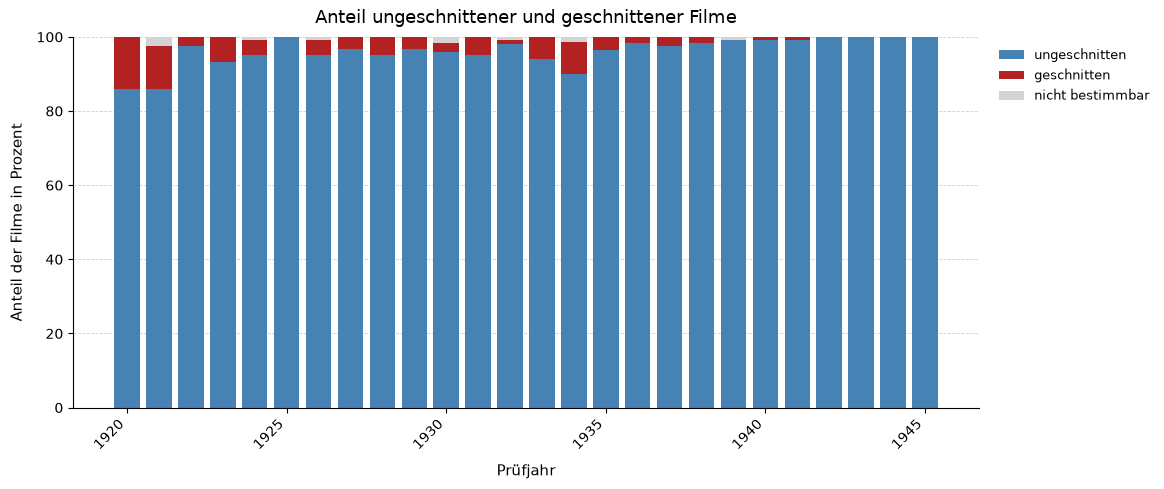

In [24]:
plot_data = yearly_length
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

ax.bar(
    plot_data.index,
    plot_data["uncut_share_percent"],
    label="ungeschnitten",
    color="steelblue",
)
ax.bar(
    plot_data.index,
    plot_data["cut_share_percent"],
    bottom=plot_data["uncut_share_percent"],
    label="geschnitten",
    color="firebrick",
)
ax.bar(
    plot_data.index,
    plot_data["records_cut_status_unknown"]
    .div(plot_data["records"])
    .mul(100),
    bottom=plot_data["uncut_share_percent"] + plot_data["cut_share_percent"],
    label="nicht bestimmbar",
    color="lightgray",
)
format_plot(ax, "Anteil ungeschnittener und geschnittener Filme", "Anteil der Filme in Prozent")
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

finish_plot(fig, with_legend=True)
save_plts(fig, "plots/content/cut_shares_by_year.png")
plt.show()

### Individual Acts
- durchschnittliche Akt anzahl?
    - min/max auch zeigen?
- durchschnittliche länge pro Akt?
- länge der einzelen acts??!

In [25]:
df_filmlength_acts = (
    df_filmlength
    .explode("length_details_individual_acts", ignore_index=True)
    .dropna(subset=["length_details_individual_acts"])
    .reset_index(drop=True)
)

df_filmlength_acts = pd.concat(
    [
        df_filmlength_acts.drop(columns="length_details_individual_acts"),
        pd.json_normalize(df_filmlength_acts["length_details_individual_acts"]),
    ],
    axis=1,
)

df_filmlength_acts["original_length"] = df_filmlength_acts["original_length"].apply(parse_meters)
df_filmlength_acts["length_after_cut"] = df_filmlength_acts["length_after_cut"].apply(parse_meters)

df_filmlength_acts["is_synthetic_act"] = False
no_individual_acts = df_filmlength["length_details_individual_acts"].map(
    lambda acts: not isinstance(acts, list) or len(acts) == 0
)
synthetic_acts = df_filmlength.loc[no_individual_acts].drop(
    columns="length_details_individual_acts"
).copy()
synthetic_acts["act_number"] = "Gesamtfilm"
synthetic_acts["original_length"] = synthetic_acts["total_original_length_parsed"]
synthetic_acts["length_after_cut"] = synthetic_acts["length_after_cut_for_analysis"]
synthetic_acts["is_synthetic_act"] = True
df_filmlength_acts = pd.concat(
    [df_filmlength_acts, synthetic_acts],
    ignore_index=True,
    sort=False,
)

df_filmlength_acts["act_length_after_cut_for_analysis"] = (
    df_filmlength_acts["length_after_cut"]
)
known_cut_status = df_filmlength_acts["cut_status"].isin(
    ["geschnitten", "ungeschnitten"]
)
unchanged_acts = known_cut_status & df_filmlength_acts["length_after_cut"].isna()
df_filmlength_acts.loc[unchanged_acts, "act_length_after_cut_for_analysis"] = (
    df_filmlength_acts.loc[unchanged_acts, "original_length"]
)

df_filmlength_acts

,_file_name,movie_title,metadata_year,metadata_Entscheidung,metadata_Länge_parsed,total_original_length_parsed,total_length_after_cut_parsed,cut_length_in_acts_available,cut_length_available,uncut_inferred,...,length_after_cut_for_analysis,cut_status,films_with_cut,films_without_cut,cut_status_unknown,act_number,original_length,length_after_cut,is_synthetic_act,act_length_after_cut_for_analysis
0,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,False,False,True,...,498.0,ungeschnitten,False,True,False,I,260.0,NaN,False,260.0
1,R 9346-I_7746_processed.json,Liebestoll.,1925,Jugendverbot,498.0,498.0,NaN,False,False,True,...,498.0,ungeschnitten,False,True,False,II,238.0,NaN,False,238.0
2,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,2991.0,ungeschnitten,False,True,False,1. Rolle 1. Akt,334.0,NaN,False,334.0
3,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,2991.0,ungeschnitten,False,True,False,2. Rolle 2. u. 3. Akt,536.0,NaN,False,536.0
4,R 9346-I_35012_processed.json,Die Entlassung.,1942,Jugendfrei vom 14. Lebensjahr ab,2991.0,2991.0,NaN,False,False,True,...,2991.0,ungeschnitten,False,True,False,3. Rolle 4. u. 5. Akt,559.0,NaN,False,559.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6914,R 9346-I_20112_processed.json,Serien-Reklame.,1931,Jugendfrei,89.0,89.0,NaN,False,False,True,...,89.0,ungeschnitten,False,True,False,Gesamtfilm,89.0,89.0,True,89.0
6915,R 9346-I_35216_processed.json,Mutti hat Geburtstag.,1942,Jugendfrei,83.0,89.0,NaN,False,False,True,...,89.0,ungeschnitten,False,True,False,Gesamtfilm,89.0,89.0,True,89.0
6916,R 9346-I_7021_processed.json,Bad Galzellen.,1925,Jugendfrei,220.0,220.0,NaN,False,False,True,...,220.0,ungeschnitten,False,True,False,Gesamtfilm,220.0,220.0,True,220.0
6917,R 9346-I_5875_processed.json,Gehöhrte Räuber.,1924,Jugendfrei,393.0,393.0,NaN,False,False,True,...,393.0,ungeschnitten,False,True,False,Gesamtfilm,393.0,393.0,True,393.0


keine Einzelaktangaben ==> ein akt???

In [26]:
df_filmlength["has_individual_acts"] = df_filmlength["length_details_individual_acts"].map(
    lambda acts: isinstance(acts, list) and len(acts) > 0
)
df_filmlength["act_count"] = df_filmlength["length_details_individual_acts"].map(
    lambda acts: len(acts) if isinstance(acts, list) and len(acts) > 0 else 1
)

yearly_individual_acts = (
    df_filmlength.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        records=("_file_name", "count"),
        films_with_individual_acts=("has_individual_acts", "sum"),
        films_without_individual_acts=("has_individual_acts", lambda values: (~values).sum()),
        total_acts=("act_count", "sum"),
        mean_act_count=("act_count", "mean"),
        median_act_count=("act_count", "median"),
    )
)

yearly_act_lengths = (
    df_filmlength_acts.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        acts_with_original_length=("original_length", "count"),
        mean_act_length=("original_length", "mean"),
        median_act_length=("original_length", "median"),
        acts_with_after_cut_length=("act_length_after_cut_for_analysis", "count"),
        mean_act_length_after_cut=("act_length_after_cut_for_analysis", "mean"),
        median_act_length_after_cut=("act_length_after_cut_for_analysis", "median"),
    )
)

yearly_individual_acts = yearly_individual_acts.join(yearly_act_lengths)
yearly_individual_acts["acts_with_original_length"] = (
    yearly_individual_acts["acts_with_original_length"]
    .fillna(0)
    .astype("Int64")
)
yearly_individual_acts["acts_with_after_cut_length"] = (
    yearly_individual_acts["acts_with_after_cut_length"]
    .fillna(0)
    .astype("Int64")
)
yearly_individual_acts.round(2)

,records,films_with_individual_acts,films_without_individual_acts,total_acts,mean_act_count,median_act_count,acts_with_original_length,mean_act_length,median_act_length,acts_with_after_cut_length,mean_act_length_after_cut,median_act_length_after_cut
metadata_year,,,,,,,,,,,,
1920,71,53,18,273,3.85,5.0,272,326.72,328.5,272,326.70,331.3
1921,120,80,40,394,3.28,3.0,390,315.59,308.0,374,313.69,305.5
1922,120,56,64,314,2.62,1.0,311,292.39,295.0,311,292.34,295.0
1923,120,73,47,368,3.07,2.0,366,302.46,298.0,366,302.66,298.0
1924,120,74,46,378,3.15,2.0,377,308.28,299.0,376,308.16,299.5
1925,120,60,60,295,2.46,1.5,293,306.45,291.0,293,306.45,291.0
1926,120,46,74,290,2.42,1.0,286,300.66,295.0,282,296.85,293.0
1927,120,45,75,289,2.41,1.0,288,274.88,287.0,288,274.74,287.0
1928,120,45,75,287,2.39,1.0,286,279.96,291.0,286,276.55,289.0


### Dokumente mit und ohne Einzelaktangaben pro Jahr

Ein Dokument zählt als "mit Einzelaktangaben", wenn `length_details_individual_acts` mindestens einen Akt enthält. Der synthetische Eintrag `Gesamtfilm` wird dabei nicht als Akt gezählt.

In [27]:
yearly_act_document_counts = (
    yearly_individual_acts[
        [
            "records",
            "films_with_individual_acts",
            "films_without_individual_acts",
        ]
    ]
    .rename(
        columns={
            "records": "Dokumente insgesamt",
            "films_with_individual_acts": "mit Einzelaktangaben",
            "films_without_individual_acts": "ohne Einzelaktangaben",
        }
    )
    .astype("Int64")
)
yearly_act_document_counts.index.name = "Prüfjahr"

yearly_act_document_counts

,Dokumente insgesamt,mit Einzelaktangaben,ohne Einzelaktangaben
Prüfjahr,,,
1920,71,53,18
1921,120,80,40
1922,120,56,64
1923,120,73,47
1924,120,74,46
1925,120,60,60
1926,120,46,74
1927,120,45,75
1928,120,45,75


#### Plots

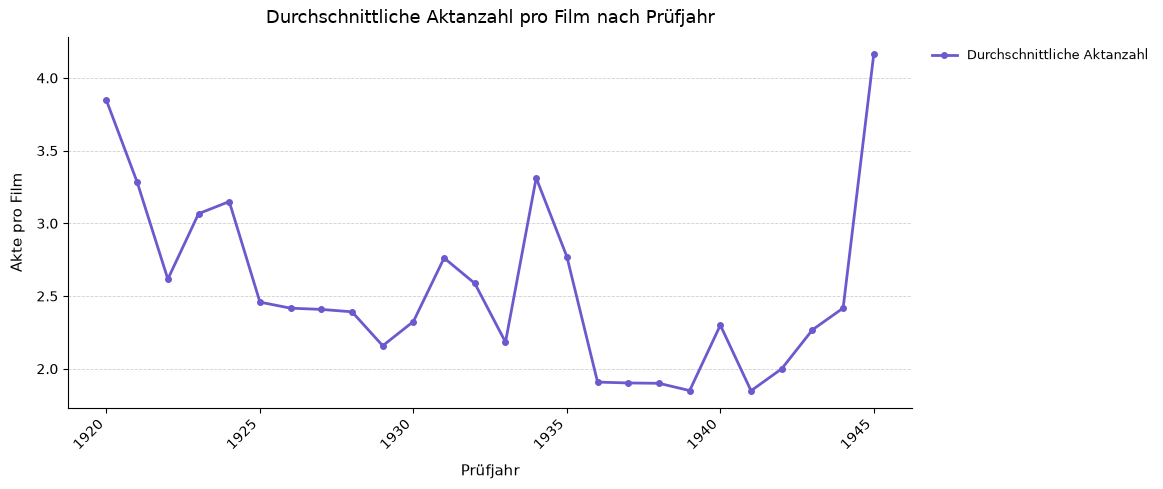

In [28]:
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

ax.plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_count"],
    marker="o",
    linewidth=2,
    markersize=4,
    color="slateblue",
    label="Durchschnittliche Aktanzahl",
)
format_plot(ax, "Durchschnittliche Aktanzahl pro Film nach Prüfjahr", "Akte pro Film")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

finish_plot(fig, with_legend=True)
save_plts(fig, "plots/content/act_counts_by_year.png")
plt.show()

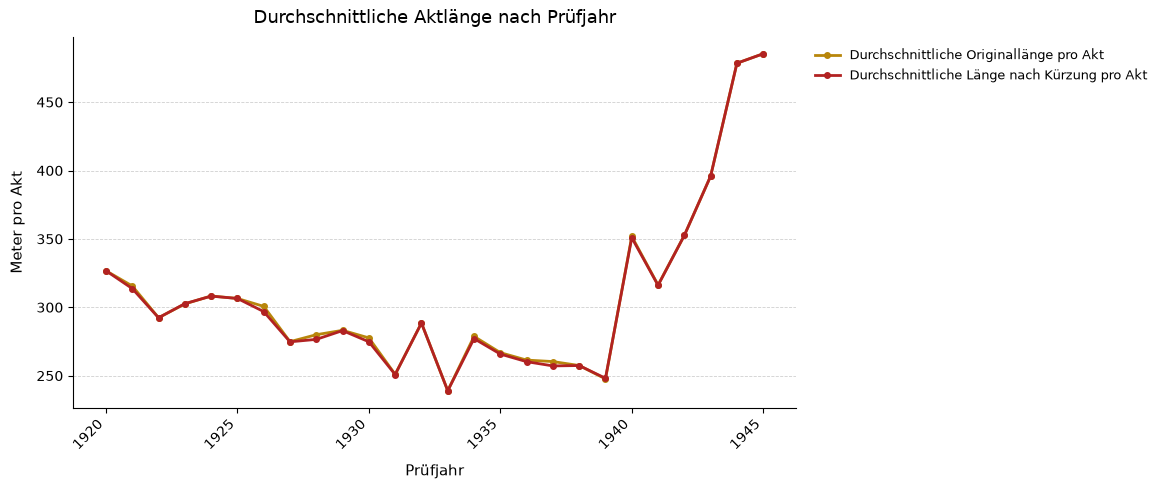

In [29]:
fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

ax.plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_length"],
    marker="o",
    linewidth=2,
    markersize=4,
    color="darkgoldenrod",
    label="Durchschnittliche Originallänge pro Akt",
)
ax.plot(
    yearly_individual_acts.index,
    yearly_individual_acts["mean_act_length_after_cut"],
    marker="o",
    linewidth=2,
    markersize=4,
    color="firebrick",
    label="Durchschnittliche Länge nach Kürzung pro Akt",
)
format_plot(ax, "Durchschnittliche Aktlänge nach Prüfjahr", "Meter pro Akt")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

finish_plot(fig, with_legend=True)
save_plts(fig, "plots/content/act_lengths_by_year.png")
plt.show()

### Cuts & Decision

In [30]:
decision_cut_summary = (
    df_filmlength.assign(
        decision=df_filmlength["metadata_Entscheidung"].fillna("(fehlend)")
    )
    .groupby("decision")
    .agg(
        records=("_file_name", "count"),
        records_with_cut_status=("cut_status", lambda values: values.ne("nicht bestimmbar").sum()),
        films_with_cut=("films_with_cut", "sum"),
        films_without_cut=("films_without_cut", "sum"),
        records_cut_status_unknown=("cut_status_unknown", "sum"),
    )
    .sort_values("films_with_cut", ascending=False)
)

decision_cut_summary["cut_share_percent"] = (
    decision_cut_summary["films_with_cut"]
    .div(decision_cut_summary["records"])
    .mul(100)
)

decision_cut_summary.round(2)

,records,records_with_cut_status,films_with_cut,films_without_cut,records_cut_status_unknown,cut_share_percent
decision,,,,,,
Jugendverbot,676,669,63,606,7,9.32
Jugendfrei,2094,2092,30,2062,2,1.43
(fehlend),8,7,0,7,1,0.00
Jugendfrei vom 14. Lebensjahr ab,44,44,0,44,0,0.00
nur für bestimmte Personengruppen,2,2,0,2,0,0.00


## Film-Prüfstelle vs. Film-Prüfstelle Berlin

In [31]:
yearly_examination = (
    df.groupby(
        [
            "metadata_year",
            "examination_certificate_examination_board",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
yearly_examination


examination_certificate_examination_board,Film-Prüfselle,Film-Prüfsielle,Film-Prüfsstelle,Film-Prüfstelle,Film-Prüfstelle Berlin,"Film-Prüfstelle, Berlin",Film-Prükstelle Berlin,Film-Prÿstelle,Film-Prÿstelle Berlin,Film-prüfstelle Berlin,Film-Üprücälle Berlin,Filmprüfstelle,Filmprüfstelle Berlin,Filmprüfung G/C015,film-Prüfstelle Berlin
metadata_year,,,,,,,,,,,,,,,
1920,0,0,0,1,69,0,0,0,0,0,0,0,0,0,1
1921,0,0,0,3,113,1,0,0,1,0,0,0,0,0,2
1922,0,0,0,2,111,0,0,0,0,0,0,0,0,0,7
1923,0,0,0,1,112,0,1,0,2,1,0,0,1,0,2
1924,0,0,0,2,115,0,0,0,1,0,0,0,0,0,2
1925,0,0,0,0,119,0,0,0,0,0,1,0,0,0,0
1926,0,0,0,0,115,0,0,0,0,0,0,2,3,0,0
1927,0,0,0,1,119,0,0,0,0,0,0,0,0,0,0
1928,0,0,0,4,115,0,0,0,0,0,0,0,1,0,0


In [32]:
# replace ocr errors => make comparable
mapping = {
    "Film-Prüfselle" : "Film-Prüfstelle",
    "Film-Prüfsielle" : "Film-Prüfstelle",
    "Film-Prüfsstelle" : "Film-Prüfstelle",
    "Film-Prÿstelle" : "Film-Prüfstelle",

    "Filmprüfstelle" : "Film-Prüfstelle",

    "Film-Prüfstelle, Berlin" : "Film-Prüfstelle Berlin",
    "Film-Prükstelle Berlin" : "Film-Prüfstelle Berlin",
    "Film-Prÿstelle Berlin" : "Film-Prüfstelle Berlin",
    "Film-prüfstelle Berlin" : "Film-Prüfstelle Berlin",
    "Film-Üprücälle Berlin" : "Film-Prüfstelle Berlin",
    
    "Filmprüfstelle Berlin" : "Film-Prüfstelle Berlin",
    "film-Prüfstelle Berlin" :"Film-Prüfstelle Berlin",
}

df["examination_certificate_examination_board"] = (
    df["examination_certificate_examination_board"].replace(mapping)
)

yearly_examination = (
    df.groupby(
        [
            "metadata_year",
            "examination_certificate_examination_board",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
yearly_examination


examination_certificate_examination_board,Film-Prüfstelle,Film-Prüfstelle Berlin,Filmprüfung G/C015
metadata_year,,,
1920,1,70,0
1921,3,117,0
1922,2,118,0
1923,1,119,0
1924,2,118,0
1925,0,120,0
1926,2,118,0
1927,1,119,0
1928,4,116,0


Plot

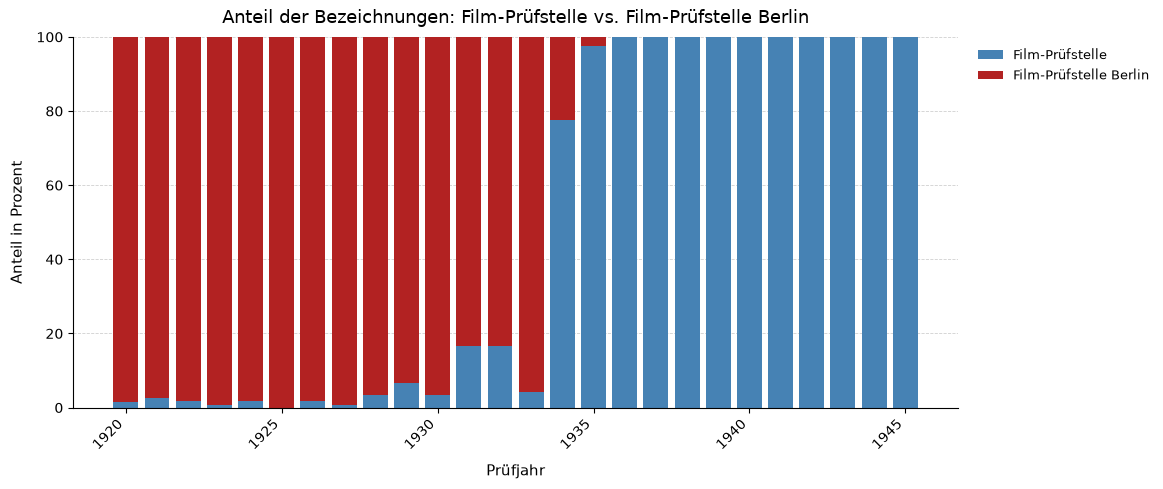

In [33]:
plot_data = yearly_examination[[
    "Film-Prüfstelle",
    "Film-Prüfstelle Berlin",
]].copy()
row_totals = plot_data.sum(axis=1).replace(0, float("nan"))
plot_data = plot_data.div(row_totals, axis=0).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

ax.bar(
    plot_data.index,
    plot_data["Film-Prüfstelle"],
    label="Film-Prüfstelle",
    color="steelblue",
)
ax.bar(
    plot_data.index,
    plot_data["Film-Prüfstelle Berlin"],
    bottom=plot_data["Film-Prüfstelle"],
    label="Film-Prüfstelle Berlin",
    color="firebrick",
)

format_plot(
    ax,
    "Anteil der Bezeichnungen: Film-Prüfstelle vs. Film-Prüfstelle Berlin",
    "Anteil in Prozent",
)
ax.set_ylim(0, 100)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)

finish_plot(fig, with_legend=True)
save_plts(fig, "plots/content/prüfstellen.png")
plt.show()

## Intertitles

In [34]:
df_intertitles = pd.json_normalize(
    records,
    record_path="intertitles",
    meta=[
        "examination_number",
        "movie_title",
        "_file_name"
    ],
    errors="ignore",
    sep="_"
)

df_intertitles

,act_label,text,examination_number,movie_title,_file_name
0,1. Akt,"1. Akt. 1. Ein junger Aduläter, der um sein Le...",11751,Liebestoll.,R 9346-I_7746_processed.json
1,Fortsetzung,"herein! 10. Komm, komm! Du kriegst den Fuß von...",11751,Liebestoll.,R 9346-I_7746_processed.json
2,2. Akt,1. Das war also Dein verlorener Käfer! 2. Bon ...,11751,Liebestoll.,R 9346-I_7746_processed.json
3,Fortsetzung,"2. Aha, sozusagen Landgüter! 3. Wie groß sein ...",38954,Die Macht der Liebe.,R 9346-I_24154_processed.json
4,Fortsetzung,"Brief. 20. Du willst schon gehen, Emil? 21. Ic...",38954,Die Macht der Liebe.,R 9346-I_24154_processed.json
...,...,...,...,...,...
10630,Fortsetzung,kommt Du ins Zuchthaus! 6. Weil ich Ihnen eine...,30403,Mann über Bord.,R 9346-I_20179_processed.json
10631,Fortsetzung,möchte ich Dir ins Spital verhelfen. 35. Wird ...,30403,Mann über Bord.,R 9346-I_20179_processed.json
10632,1. Akt,"1. William Fox gehört sich darzubieten; 2. ""Di...",7647,Die Wölfin.,R 9346-I_4696_processed.json
10633,2. Akt,1. Ende.,7647,Die Wölfin.,R 9346-I_4696_processed.json


### Topic Modeling

- BERTopic basiert auf Embeddings
- NMF arbeitet mit TF-IDF 

In [35]:
# %pip install bertopic sentence-transformers

In [36]:
import re

def intertitles_to_document(intertitles):
    if not isinstance(intertitles, list):
        return ""

    texts = [
        entry["text"]
        for entry in intertitles
        if (
            isinstance(entry, dict)
            and isinstance(entry.get("text"), str)
            and entry["text"].strip()
        )
    ]

    # Die Reihenfolge der Intertitles innerhalb des Films bleibt erhalten.
    text = "\n".join(texts)
    text = re.sub(r"(?<=\w)-\s+(?=\w)", "", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_text(text):
    # Umlaute bleiben erhalten; Zahlen und Satzzeichen werden entfernt.
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = text.replace("_", " ")
    return re.sub(r"\s+", " ", text).strip()


# Ein Dokument pro Film: alle zugehörigen Intertitles werden zusammengeführt.
df_topics = df[
    [
        "_file_name",
        "examination_number",
        "movie_title",
        "metadata_year",
        "metadata_Entscheidung",
        "intertitles",
    ]
].copy()

df_topics["document"] = df_topics["intertitles"].apply(
    intertitles_to_document
)

df_topics["document_clean"] = df_topics["document"].map(clean_text)

# Filme ohne Text können nicht modelliert werden.
df_topics = (
    df_topics.loc[df_topics["document_clean"].ne("")]
    .reset_index(drop=True)
)

docs = df_topics["document_clean"].tolist()

print(f"{len(docs)} Filme mit Intertitles")
if docs:
    print(docs[0][:500])


1558 Filme mit Intertitles
akt ein junger aduläter der um sein leben rennt um einen erschern auszugehen sehen sie mich försordorf ab das ist eine rolle zu weit gewalzt du bist ein gehaßter kerl ich nehme dich als goldbarren mit es zogen drei jungschen wohl über den rhein bei einer frau wittin da kehrten sie ein geh hinein und walte deines amtes warum so traurig mein liebes kind ich hab ganz muttersehn allein da kam ein böser hund herein komm komm du kriegst den fuß von mir noch einer der was haben möchte zu spät zu spät j


In [37]:
# pip install nltk

In [38]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

german_stop_words = stopwords.words('german')

# Eigene Begriffe hier in Kleinschreibung ergänzen.
custom_stop_words = {
    "akt",
    "akte",
    "aktes",
    "akten",
    "teil",
    "ende",
    "zwischentitel",
    "unleserlich"
}

all_stop_words = sorted(
    set(german_stop_words)
    | {word.lower() for word in custom_stop_words}
    | {"untertitel"}
)

/home/marisa/Dokumente/GitHub/german-film-censorship/statictial_analysis?/lib/python3.13/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/marisa/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


approx. duration:  2 min

In [39]:
# from bertopic import BERTopic
# from sentence_transformers import SentenceTransformer
# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer_model = CountVectorizer(
#     stop_words=all_stop_words
# )

# embedding_model = SentenceTransformer(
#     "paraphrase-multilingual-MiniLM-L12-v2"
# )

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     min_topic_size=15,
#     calculate_probabilities=True,
#     verbose=True,
# )

# topics, probabilities = topic_model.fit_transform(docs)

# df_topics["topic"] = topics
# if probabilities is not None:
#     if getattr(probabilities, "ndim", 1) == 2:
#         df_topics["topic_probability"] = probabilities.max(axis=1)
#     else:
#         df_topics["topic_probability"] = probabilities

# topic_model.get_topic_info()

In [40]:
# vectorizer_model = CountVectorizer(
#     stop_words=all_stop_words
# )

# embedding_model = SentenceTransformer(
#     "paraphrase-multilingual-MiniLM-L12-v2"
# )

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     min_topic_size=5,
#     nr_topics=15,
#     calculate_probabilities=True,
#     verbose=True,
# )

# topics, probabilities = topic_model.fit_transform(docs)

# df_topics["topic"] = topics
# if probabilities is not None:
#     if getattr(probabilities, "ndim", 1) == 2:
#         df_topics["topic_probability"] = probabilities.max(axis=1)
#     else:
#         df_topics["topic_probability"] = probabilities

# topic_model.get_topic_info()

In [41]:
# from umap import UMAP

# umap_model = UMAP(
#     n_neighbors=15,
#     n_components=5,
#     min_dist=0.0,
#     metric="cosine",
#     random_state=42,
# )

# vectorizer_model = CountVectorizer(
#     stop_words=all_stop_words
# )

# embedding_model = SentenceTransformer(
#     "paraphrase-multilingual-MiniLM-L12-v2"
# )

# topic_model = BERTopic(
#     embedding_model=embedding_model,
#     vectorizer_model=vectorizer_model,
#     umap_model=umap_model,
#     min_topic_size=5,
#     calculate_probabilities=True,
#     verbose=True,
# )


# topics, probabilities = topic_model.fit_transform(docs)

# df_topics["topic"] = topics
# if probabilities is not None:
#     if getattr(probabilities, "ndim", 1) == 2:
#         df_topics["topic_probability"] = probabilities.max(axis=1)
#     else:
#         df_topics["topic_probability"] = probabilities

# topic_model.get_topic_info()

fine tune topic representations

In [42]:
# from bertopic.representation import KeyBERTInspired

# # Fine-tune your topic representations without discarding the fitted model.
# representation_model = KeyBERTInspired()
# topic_model.update_topics(
#     docs,
#     representation_model=representation_model,
# )

# topic_model.get_topic_info()

## Intertitle Analysis

In [43]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
import numpy as np

analysis_df = df_topics.merge(
    df_filmlength[["_file_name", "cut_status", "cut_meters", "cut_rate"]],
    on="_file_name",
    how="left",
    validate="one_to_one",
).copy()
analysis_df = analysis_df.loc[analysis_df["document_clean"].ne("")].reset_index(drop=True)
analysis_df["metadata_year"] = pd.to_numeric(analysis_df["metadata_year"], errors="coerce")

def log_ratio_terms(frame, group_column, group_value, n=20, min_df=5, min_group_df=10):
    vectorizer = CountVectorizer(
        lowercase=False,
        binary=True,
        min_df=min_df,
        stop_words=all_stop_words,
    )
    X = vectorizer.fit_transform(frame["document_clean"])
    group_mask = frame[group_column].eq(group_value).to_numpy()
    other_mask = ~group_mask
    group_frequency = np.asarray(X[group_mask].sum(axis=0)).ravel()
    other_frequency = np.asarray(X[other_mask].sum(axis=0)).ravel()
    group_rate = (group_frequency + 1) / (group_mask.sum() + 2)
    other_rate = (other_frequency + 1) / (other_mask.sum() + 2)
    scores = np.log(group_rate / other_rate)
    terms = vectorizer.get_feature_names_out()
    result = pd.DataFrame({
        "term": terms,
        "log_ratio": scores,
        "group_document_frequency": group_frequency,
        "other_document_frequency": other_frequency,
    })
    result = result.loc[result["group_document_frequency"].ge(min_group_df)]
    return result.sort_values("log_ratio", ascending=False).head(n)

print(f"{len(analysis_df)} Dokumente mit Intertitle-Text")


1558 Dokumente mit Intertitle-Text


,Filme insgesamt,Filme mit Intertitles,Intertitle-Einträge,Anteil mit Intertitles (%),Intertitles pro Film
Prüfjahr,,,,,
1920,71,59,397,83.1,6.7
1921,120,97,579,80.8,6.0
1922,120,67,406,55.8,6.1
1923,120,84,493,70.0,5.9
1924,120,86,555,71.7,6.5
1925,120,67,370,55.8,5.5
1926,120,63,366,52.5,5.8
1927,120,66,358,55.0,5.4
1928,120,64,351,53.3,5.5


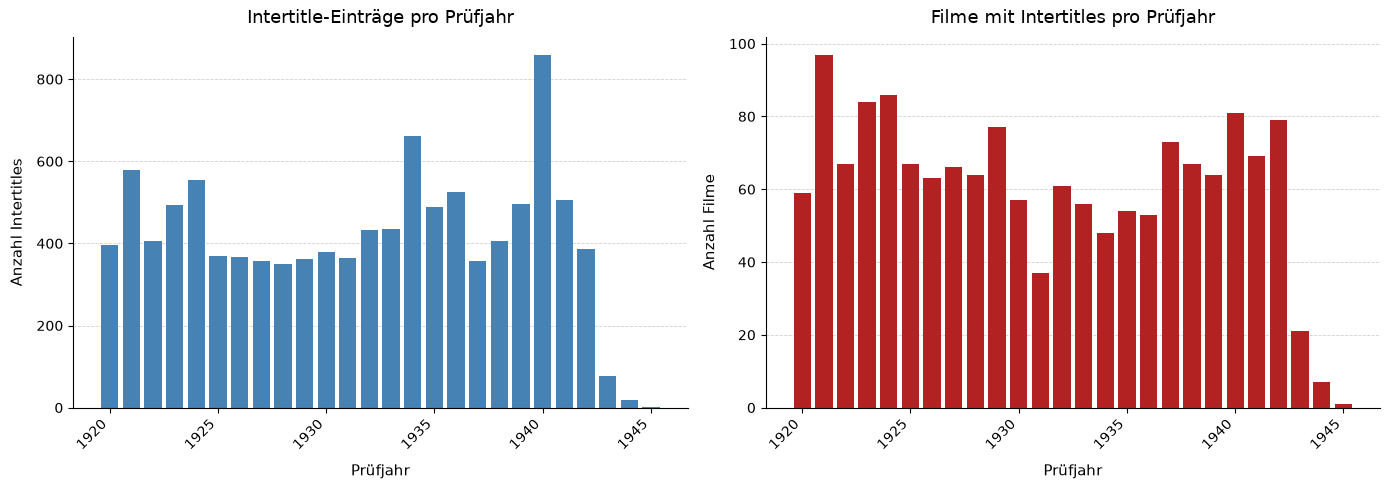

In [44]:
def count_intertitles(value):
    if not isinstance(value, list):
        return 0

    return sum(
        isinstance(entry, dict)
        and isinstance(entry.get("text"), str)
        and bool(entry["text"].strip())
        for entry in value
    )

intertitle_counts = df[["_file_name", "metadata_year", "intertitles"]].copy()
intertitle_counts["intertitle_count"] = intertitle_counts["intertitles"].apply(count_intertitles)
intertitle_counts["has_intertitles"] = intertitle_counts["intertitle_count"].gt(0)

yearly_intertitle_distribution = (
    intertitle_counts.dropna(subset=["metadata_year"])
    .groupby("metadata_year")
    .agg(
        films=("_file_name", "nunique"),
        films_with_intertitles=("has_intertitles", "sum"),
        intertitles=("intertitle_count", "sum"),
    )
    .sort_index()
)
yearly_intertitle_distribution["share_of_films_with_intertitles"] = (
    yearly_intertitle_distribution["films_with_intertitles"]
    .div(yearly_intertitle_distribution["films"])
    .mul(100)
    .round(1)
)
yearly_intertitle_distribution["intertitles_per_film_with_intertitles"] = (
    yearly_intertitle_distribution["intertitles"]
    .div(yearly_intertitle_distribution["films_with_intertitles"].replace(0, pd.NA))
    .round(1)
)

display(
    yearly_intertitle_distribution.rename(
        columns={
            "films": "Filme insgesamt",
            "films_with_intertitles": "Filme mit Intertitles",
            "intertitles": "Intertitle-Einträge",
            "share_of_films_with_intertitles": "Anteil mit Intertitles (%)",
            "intertitles_per_film_with_intertitles": "Intertitles pro Film",
        }
    ).rename_axis("Prüfjahr")
)

fig, axes = plt.subplots(1, 2, figsize=PLOT_FIGSIZE, sharex=True)
years = yearly_intertitle_distribution.index

axes[0].bar(
    years,
    yearly_intertitle_distribution["intertitles"],
    color="steelblue",
)
format_plot(axes[0], "Intertitle-Einträge pro Prüfjahr", "Anzahl Intertitles")

axes[1].bar(
    years,
    yearly_intertitle_distribution["films_with_intertitles"],
    color="firebrick",
)
format_plot(axes[1], "Filme mit Intertitles pro Prüfjahr", "Anzahl Filme")

finish_plot(fig)
save_plts(fig, "plots/content/intertitles_pro_jahr.png")
plt.show()

### Jugendfrei vs. Jugendverbot

- Wörter die in einer Entscheidungsgruppe relativ häufiger vorkommen

In [45]:
decision_df = analysis_df.loc[
    analysis_df["metadata_Entscheidung"].isin(["Jugendfrei", "Jugendverbot"])
].copy()
display(decision_df["metadata_Entscheidung"].value_counts().rename("films"))

jugendfrei_terms = log_ratio_terms(
    decision_df, "metadata_Entscheidung", "Jugendfrei"
).assign(group="Jugendfrei")
jugendverbot_terms = log_ratio_terms(
    decision_df, "metadata_Entscheidung", "Jugendverbot"
).assign(group="Jugendverbot")
display(
    pd.concat([jugendfrei_terms, jugendverbot_terms])
    [["group", "term", "log_ratio", "group_document_frequency", "other_document_frequency"]]
)

decision_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        stop_words=all_stop_words,
        min_df=5,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
    )),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    decision_model,
    decision_df["document_clean"],
    decision_df["metadata_Entscheidung"],
    cv=cv,
    scoring=["balanced_accuracy", "f1_macro"],
)
display(pd.DataFrame({
    "balanced_accuracy": cv_results["test_balanced_accuracy"],
    "f1_macro": cv_results["test_f1_macro"],
}).round(3))


metadata_Entscheidung
Jugendfrei      946
Jugendverbot    578
Name: films, dtype: int64

,group,term,log_ratio,group_document_frequency,other_document_frequency
4478,Jugendfrei,herstellung,3.064022,34,0
4601,Jugendfrei,hitler,2.504406,19,0
2728,Jugendfrei,fahnen,2.453113,18,0
1802,Jugendfrei,deutsches,2.341887,16,0
8571,Jugendfrei,tonnen,2.216724,14,0
2387,Jugendfrei,erbaut,2.147731,13,0
9692,Jugendfrei,wassers,2.147731,13,0
1804,Jugendfrei,deutschlands,2.073623,25,1
1801,Jugendfrei,deutscher,2.073623,38,2
1772,Jugendfrei,denkmal,2.073623,12,0


,balanced_accuracy,f1_macro
0,0.824,0.821
1,0.825,0.819
2,0.791,0.787
3,0.812,0.810
4,0.778,0.771


### Wiederkehrende Themen

- alternative zu Topic Modeling / BERTopic
- 10 topcis -> wichtigste Begriffe
- auch 5, 8 und 12 ausprobieren?


In [46]:
N_TOPICS = 10
theme_vectorizer = TfidfVectorizer(
    lowercase=False,
    stop_words=all_stop_words,
    min_df=10,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
X_theme = theme_vectorizer.fit_transform(analysis_df["document_clean"])
nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=42,
    max_iter=1000,
)
W = nmf_model.fit_transform(X_theme)
terms = theme_vectorizer.get_feature_names_out()

topic_rows = []
for topic_id, weights in enumerate(nmf_model.components_):
    top_indices = weights.argsort()[::-1][:15]
    for rank, index in enumerate(top_indices, start=1):
        topic_rows.append({
            "topic": topic_id,
            "rank": rank,
            "term": terms[index],
            "weight": weights[index],
        })

topic_terms = pd.DataFrame(topic_rows)
display(topic_terms.round(3))

analysis_df["nmf_topic"] = W.argmax(axis=1)
analysis_df["nmf_topic_score"] = W.max(axis=1)
display(analysis_df["nmf_topic"].value_counts().sort_index().rename("films"))

topic_summary = (
    topic_terms.loc[topic_terms["rank"].le(10)]
    .groupby("topic")["term"]
    .agg(", ".join)
    .rename("top_terms")
)
display(topic_summary.to_frame())

,topic,rank,term,weight
0,0,1,herr,0.449
1,0,2,frau,0.380
2,0,3,mann,0.327
3,0,4,muß,0.324
4,0,5,mehr,0.313
...,...,...,...,...
145,9,11,großaufnahme,0.096
146,9,12,modernen,0.094
147,9,13,läuft,0.087
148,9,14,wahrheit,0.086


nmf_topic
0    267
1     95
2    140
3    127
4    209
5     36
6    156
7    276
8    202
9     50
Name: films, dtype: int64

,top_terms
topic,
0,"herr, frau, mann, muß, mehr, brief, heute, her..."
1,"florence, irrenhaus, damals, henry, unterdrück..."
2,"bittet, sagt, fragt, kommt, erklärt, erzählt, ..."
3,"schiff, bord, fahrt, dampfer, hafen, boot, see..."
4,"ja, na, ach, mal, nein, schön, ja ja, gar, bit..."
5,"dr munson, munson, reedcliffe, ertrunken, dr, ..."
6,"deutschen, deutsche, deutschland, stadt, berli..."
7,"wasser, herstellung, großen, maschine, arbeit,..."
8,"mutter, leben, welt, vater, kind, liebe, mehr,..."


### Zeitliche Veränderungen

- wichtigste Wörter pro Jahrzent
- jahrzent < 20 dokumente => rausgelassen

In [47]:
time_df = analysis_df.dropna(subset=["metadata_year"]).copy().reset_index(drop=True)
time_df["decade"] = (time_df["metadata_year"].astype(int) // 10) * 10
time_vectorizer = CountVectorizer(
    lowercase=False,
    binary=True,
    min_df=5,
    stop_words=all_stop_words,
)
X_time = time_vectorizer.fit_transform(time_df["document_clean"])
time_terms = time_vectorizer.get_feature_names_out()
time_rows = []

for decade, group in time_df.groupby("decade", sort=True):
    positions = group.index.to_numpy()
    if len(positions) < 20 or len(positions) == len(time_df):
        continue
    rest_positions = np.setdiff1d(np.arange(len(time_df)), positions)
    decade_frequency = np.asarray(X_time[positions].sum(axis=0)).ravel()
    rest_frequency = np.asarray(X_time[rest_positions].sum(axis=0)).ravel()
    decade_rate = (decade_frequency + 1) / (len(positions) + 2)
    rest_rate = (rest_frequency + 1) / (len(rest_positions) + 2)
    scores = np.log(decade_rate / rest_rate)
    valid_indices = np.flatnonzero(decade_frequency >= 10)
    top_indices = valid_indices[np.argsort(scores[valid_indices])[::-1][:15]]
    for index in top_indices:
        time_rows.append({
            "decade": decade,
            "films": len(positions),
            "term": time_terms[index],
            "log_ratio": scores[index],
        })

time_terms_table = pd.DataFrame(time_rows)
display(time_terms_table.round(3))

if "nmf_topic" in time_df.columns:
    topic_share_by_decade = pd.crosstab(
        time_df["decade"],
        time_df["nmf_topic"],
        normalize="index",
    )
    display(topic_share_by_decade.round(3))


,decade,films,term,log_ratio
0,1920,730,gefürgt,2.959
1,1920,730,kehrte,2.765
2,1920,730,letzt,2.765
3,1920,730,zonen,2.691
4,1920,730,mar,2.611
5,1920,730,region,2.524
6,1920,730,häufige,2.524
7,1920,730,fich,2.524
8,1920,730,gordon,2.524
9,1920,730,jhr,2.524


nmf_topic,0,1,2,3,4,5,6,7,8,9
decade,,,,,,,,,,
1920,0.303,0.126,0.007,0.064,0.023,0.045,0.070,0.163,0.182,0.016
1930,0.068,0.004,0.165,0.082,0.226,0.005,0.132,0.181,0.091,0.046
1940,0.027,0.004,0.159,0.128,0.244,0.000,0.116,0.209,0.066,0.047


### Zusammenhang mit Schnitten

- cut vs uncut films
- häufigere begriffe je gruppe

In [48]:
cut_df = analysis_df.loc[
    analysis_df["cut_status"].isin(["geschnitten", "ungeschnitten"])
].copy()
display(cut_df["cut_status"].value_counts().rename("films"))

cut_terms = log_ratio_terms(
    cut_df, "cut_status", "geschnitten"
).assign(group="geschnitten")
uncut_terms = log_ratio_terms(
    cut_df, "cut_status", "ungeschnitten"
).assign(group="ungeschnitten")
display(
    pd.concat([cut_terms, uncut_terms])
    [["group", "term", "log_ratio", "group_document_frequency", "other_document_frequency"]]
)

cut_summary = (
    cut_df.groupby("cut_status")
    .agg(
        films=("_file_name", "count"),
        mean_cut_rate=("cut_rate", "mean"),
        median_cut_rate=("cut_rate", "median"),
    )
)
display(cut_summary.round(3))

if "nmf_topic" in cut_df.columns:
    topic_cut_share = pd.crosstab(
        cut_df["nmf_topic"],
        cut_df["cut_status"],
        normalize="index",
    )
    display(topic_cut_share.round(3))


cut_status
ungeschnitten    1465
geschnitten        85
Name: films, dtype: int64

,group,term,log_ratio,group_document_frequency,other_document_frequency
6025,geschnitten,länge,1.726454,10,32
4049,geschnitten,gezeigt,1.639443,10,35
6579,geschnitten,nahm,1.372814,10,46
9246,geschnitten,verboten,1.313609,14,67
10729,geschnitten,übergeben,1.310939,10,49
8771,geschnitten,titel,1.272787,17,84
8893,geschnitten,trotz,1.145424,10,58
9589,geschnitten,versuchen,1.140727,17,96
16,geschnitten,abends,1.133391,20,113
6428,geschnitten,munson,1.131747,15,86


,films,mean_cut_rate,median_cut_rate
cut_status,,,
geschnitten,85,0.046,0.007
ungeschnitten,1465,0.000,0.000


cut_status,geschnitten,ungeschnitten
nmf_topic,,
0,0.102,0.898
1,0.064,0.936
2,0.079,0.921
3,0.047,0.953
4,0.033,0.967
5,0.206,0.794
6,0.019,0.981
7,0.018,0.982
8,0.060,0.940
